# Monte Carlo Simulation of Flood-Related Financial Loss in South Africa

## Project Overview
This project models the financial impact of flood events in South Africa using a Monte Carlo simulation approach.

The objective is to:
- Estimate Expected Annual Loss (EAL)
- Measure tail risk using Value at Risk (VaR)
- Understand the probability of extreme flood losses

This simplified catastrophe model demonstrates how probabilistic methods are used in reinsurance analytics.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility

In [23]:
# Annual probability that a flood occurs
flood_probability = 0.3  # 30% chance per year

# Severity probabilities (conditional on flood occurring)
severity_levels = ["Minor", "Moderate", "Severe"]
severity_probabilities = [0.6, 0.3, 0.1]

# Loss values in South African Rand (ZAR)
loss_values = {
    "Minor": 5_000_000,
    "Moderate": 25_000_000,
    "Severe": 100_000_000
}

# Number of simulated years
n_simulations = 10000

In [24]:
annual_losses = []

for _ in range(n_simulations):

    flood_occurs = np.random.rand() < flood_probability

    if flood_occurs:

        severity = np.random.choice(severity_levels, p=severity_probabilities)

        if severity == "Minor":
            loss = np.random.uniform(2_000_000, 10_000_000)

        elif severity == "Moderate":
            loss = np.random.uniform(10_000_000, 40_000_000)

        else:  # Severe
            loss = np.random.uniform(40_000_000, 150_000_000)

    else:
        loss = 0

    annual_losses.append(loss)

annual_losses = np.array(annual_losses)

In [25]:
expected_annual_loss = np.mean(annual_losses)
var_95 = np.percentile(annual_losses, 95)
prob_exceed_50m = np.mean(annual_losses > 50_000_000)

expected_annual_loss, var_95, prob_exceed_50m

(np.float64(5942027.703900349),
 np.float64(31784767.163138613),
 np.float64(0.026))

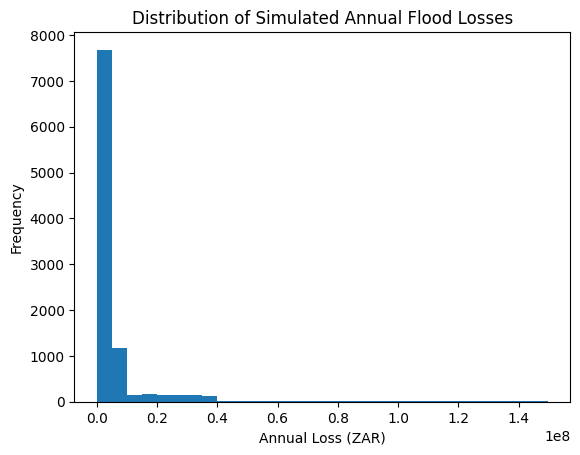

In [26]:
plt.figure()
plt.hist(annual_losses, bins=30)
plt.xlabel("Annual Loss (ZAR)")
plt.ylabel("Frequency")
plt.title("Distribution of Simulated Annual Flood Losses")
plt.show()

## Interpretation of Results

- The Expected Annual Loss (EAL) represents the average financial impact of floods per year.
- The 95% Value at Risk indicates the loss level not exceeded in 95% of simulated years.
- The probability of losses exceeding R50 million provides insight into extreme tail risk.

This demonstrates how probabilistic modelling can support reinsurance decision-making.

In [27]:
# Tail Value at Risk (TVaR 95%)

var_95 = np.percentile(annual_losses, 95)

tvar_95 = annual_losses[annual_losses >= var_95].mean()

tvar_95

np.float64(69372041.9192844)

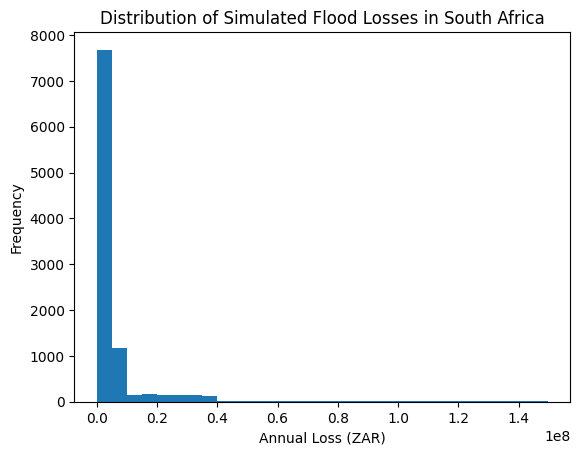

In [28]:
plt.figure()
plt.hist(annual_losses, bins=30)
plt.xlabel("Annual Loss (ZAR)")
plt.ylabel("Frequency")
plt.title("Distribution of Simulated Flood Losses in South Africa")
plt.savefig("flood_loss_distribution.png")
plt.show()